# 🌍 Sénégal Environmental Monitoring — Espace d'analyse

Ce notebook te connecte directement au **Data Lake MinIO** et au **cluster Kafka**.
Les données sont stockées en **format Parquet** (raw-data et processed-data).

| Service | Accès |
|---|---|
| MinIO `raw-data` | `minio:9000` — données brutes |
| MinIO `processed-data` | `minio:9000` — données nettoyées |
| Kafka brokers | `kafka1:9092`, `kafka2:9093`, `kafka3:9094` |
| Topic | `senegal-meteo` |



## 0. Installation des dépendances

In [16]:
import subprocess
subprocess.run(['pip', 'install', '-q', 'minio', 'kafka-python',
                'pyarrow', 'matplotlib', 'seaborn', 'plotly', 'scipy'], check=True)
print('✅ Dépendances installées')

✅ Dépendances installées


## 1. Connexion MinIO + chargement des données (Parquet)

In [17]:
import io
import pandas as pd
from minio import Minio

# Connexion au serveur MinIO
client = Minio('minio:9000', access_key='minioadmin',
               secret_key='minioadmin', secure=False)

print('📦 Buckets disponibles :')
for b in client.list_buckets():
    print(f'  {b.name}')

📦 Buckets disponibles :
  analytics
  processed-data
  raw-data


In [18]:
# Fonction pour charger les fichiers Parquet d'un bucket
def load_parquet(bucket: str, prefix: str = '') -> pd.DataFrame:
    frames = []
    objects = list(client.list_objects(bucket, prefix=prefix, recursive=True))
    print(f'{len(objects)} fichiers trouvés...')
    for i, obj in enumerate(objects):
        try:
            buf = io.BytesIO(client.get_object(bucket, obj.object_name).read())
            frames.append(pd.read_parquet(buf))
        except Exception as e:
            print(f'Erreur sur {obj.object_name}: {e}')
        if (i+1) % 50 == 0:
            print(f'  {i+1}/{len(objects)} chargés...')
    if not frames:
        return pd.DataFrame()
    df = pd.concat(frames, ignore_index=True)
    df['time'] = pd.to_datetime(df['time'])
    return df.sort_values('time').reset_index(drop=True)

df_proc = load_parquet('processed-data')
print(f'\n✅ {len(df_proc)} lignes chargées')
print(f'Colonnes : {df_proc.columns.tolist()}')
print(f'Régions  : {df_proc["region"].unique() if "region" in df_proc.columns else "colonne region absente"}')
display(df_proc.head(3))

1953 fichiers trouvés...
  50/1953 chargés...
  100/1953 chargés...
  150/1953 chargés...
  200/1953 chargés...
  250/1953 chargés...
  300/1953 chargés...
  350/1953 chargés...
  400/1953 chargés...
  450/1953 chargés...
  500/1953 chargés...
  550/1953 chargés...
  600/1953 chargés...
  650/1953 chargés...
  700/1953 chargés...
  750/1953 chargés...
  800/1953 chargés...
  850/1953 chargés...
  900/1953 chargés...
  950/1953 chargés...
  1000/1953 chargés...
  1050/1953 chargés...
  1100/1953 chargés...
  1150/1953 chargés...
  1200/1953 chargés...
  1250/1953 chargés...
  1300/1953 chargés...
  1350/1953 chargés...
  1400/1953 chargés...
  1450/1953 chargés...
  1500/1953 chargés...
  1550/1953 chargés...
  1600/1953 chargés...
  1650/1953 chargés...
  1700/1953 chargés...
  1750/1953 chargés...
  1800/1953 chargés...
  1850/1953 chargés...
  1900/1953 chargés...
  1950/1953 chargés...

✅ 1953 lignes chargées
Colonnes : ['source', 'time', 'region', 'region_code', 'lat', 'lon', 'temp

,source,time,region,region_code,lat,lon,temp,temp_feels,hum,pressure,wind_speed,wind_dir,weather_code,processed_at,quality_flag,weather_label
0,open-meteo,2026-05-14 16:57:02.066961+00:00,Dakar,DK,14.6928,-17.4467,22.70,21.90,68.0,1009.5,21.30,355,2,2026-05-14T16:57:07.454032+00:00,OK,NaN
1,openweathermap,2026-05-14 16:57:06.385762+00:00,Dakar,DK,14.6928,-17.4467,22.93,23.39,81.0,1011.0,6.17,320,802,2026-05-14T16:57:07.349914+00:00,OK,partiellement nuageux
2,open-meteo,2026-05-14 16:57:10.054914+00:00,Thiès,TH,14.7886,-16.9255,26.20,25.00,50.0,1001.4,19.70,337,3,2026-05-14T16:57:14.433028+00:00,OK,NaN


## 2. Aperçu des données

In [19]:
# Afficher un aperçu des données
display(df_proc.head(10))
# Vérifier les colonnes et les valeurs nulles
print('\nColonnes :', df_proc.columns.tolist())
print('Nulls :', df_proc.isnull().sum().to_dict())

,source,time,region,region_code,lat,lon,temp,temp_feels,hum,pressure,wind_speed,wind_dir,weather_code,processed_at,quality_flag,weather_label
0,open-meteo,2026-05-14 16:57:02.066961+00:00,Dakar,DK,14.6928,-17.4467,22.70,21.90,68.0,1009.5,21.30,355,2,2026-05-14T16:57:07.454032+00:00,OK,NaN
1,openweathermap,2026-05-14 16:57:06.385762+00:00,Dakar,DK,14.6928,-17.4467,22.93,23.39,81.0,1011.0,6.17,320,802,2026-05-14T16:57:07.349914+00:00,OK,partiellement nuageux
2,open-meteo,2026-05-14 16:57:10.054914+00:00,Thiès,TH,14.7886,-16.9255,26.20,25.00,50.0,1001.4,19.70,337,3,2026-05-14T16:57:14.433028+00:00,OK,NaN
3,openweathermap,2026-05-14 16:57:14.336558+00:00,Thiès,TH,14.7886,-16.9255,26.08,26.08,52.0,1010.0,6.15,328,804,2026-05-14T16:57:14.466256+00:00,OK,couvert
4,open-meteo,2026-05-14 16:57:20.260413+00:00,Diourbel,DB,14.6554,-16.2322,34.30,33.70,31.0,1007.0,14.90,305,1,2026-05-14T16:57:24.891399+00:00,OK,NaN
5,openweathermap,2026-05-14 16:57:24.599260+00:00,Diourbel,DB,14.6554,-16.2322,35.09,36.79,38.0,1008.0,3.09,360,800,2026-05-14T16:57:24.786491+00:00,OK,ciel dégagé
6,open-meteo,2026-05-14 16:57:28.358351+00:00,Fatick,FK,14.3390,-16.4114,34.80,35.00,32.0,1007.6,11.80,293,1,2026-05-14T16:57:32.882068+00:00,OK,NaN
7,openweathermap,2026-05-14 16:57:32.669171+00:00,Fatick,FK,14.3390,-16.4114,31.87,31.45,36.0,1009.0,6.15,241,802,2026-05-14T16:57:32.999631+00:00,OK,partiellement nuageux
8,open-meteo,2026-05-14 16:57:38.578288+00:00,Kaolack,KL,14.1652,-16.0726,36.00,35.60,28.0,1007.1,14.10,281,1,2026-05-14T16:57:43.133087+00:00,OK,NaN
9,openweathermap,2026-05-14 16:57:42.949864+00:00,Kaolack,KL,14.1652,-16.0726,35.97,37.18,34.0,1008.0,4.12,320,800,2026-05-14T16:57:43.569751+00:00,OK,ciel dégagé



Colonnes : ['source', 'time', 'region', 'region_code', 'lat', 'lon', 'temp', 'temp_feels', 'hum', 'pressure', 'wind_speed', 'wind_dir', 'weather_code', 'processed_at', 'quality_flag', 'weather_label']
Nulls : {'source': 0, 'time': 0, 'region': 0, 'region_code': 0, 'lat': 0, 'lon': 0, 'temp': 0, 'temp_feels': 0, 'hum': 0, 'pressure': 0, 'wind_speed': 0, 'wind_dir': 0, 'weather_code': 0, 'processed_at': 0, 'quality_flag': 0, 'weather_label': 973}


In [20]:
# Statistiques par région
cols = [c for c in ['temp','hum','pressure','wind_speed'] if c in df_proc.columns]
display(df_proc.groupby('region')[cols].describe().round(2))

temp                                                    hum  \
             count   mean   std    min    25%    50%    75%    max  count   
region                                                                      
Dakar        138.0  21.80  0.74  20.70  21.25  21.81  22.37  22.93  138.0   
Diourbel     139.0  29.64  3.85  23.45  25.32  30.80  32.50  35.09  139.0   
Fatick       142.0  29.12  3.05  24.10  26.40  29.26  31.87  34.80  142.0   
Kaffrine     142.0  32.32  3.03  27.49  29.30  32.55  35.42  36.30  142.0   
Kaolack      141.0  31.72  3.44  25.39  28.61  32.97  34.97  36.00  141.0   
Kolda        138.0  35.92  2.93  31.29  33.62  36.39  38.05  41.05  138.0   
Kédougou     142.0  35.63  2.54  32.03  33.20  35.30  39.31  39.31  142.0   
Louga        140.0  24.16  2.81  19.96  22.38  23.80  26.83  30.00  140.0   
Matam        139.0  38.36  2.20  34.80  36.14  38.59  40.30  41.41  139.0   
Saint-Louis  139.0  21.31  1.39  19.76  20.12  21.10  22.20  24.70  139.0   
Sédhiou      136.0  32.79  3.09  27.74  30.06  33.59  35.48  37.53  136.0   
Tambacounda  140.0  38.73  2.16  33.80  37.62  39.12  41.12  41.12  140.0   
Thiès        139.0  23.02  1.69  20.60  21.20  23.08  24.90  26.20  139.0   
Ziguinchor   138.0  28.60  2.61  24.50  26.03  29.03  30.20  34.03  138.0   

                    ... pressure         wind_speed                           \
              mean  ...      75%     max      count   mean   std   min   25%   
region              ...                                                        
Dakar        79.75  ...   1011.5  1013.0      138.0  11.73  7.13  2.24  5.14   
Diourbel     43.48  ...   1009.8  1011.0      139.0  10.57  5.77  3.09  5.14   
Fatick       43.40  ...   1010.0  1011.0      142.0  10.38  5.65  3.98  5.17   
Kaffrine     34.30  ...   1009.0  1011.0      142.0  11.77  4.74  6.11  7.71   
Kaolack      41.66  ...   1010.0  1011.0      141.0  10.00  4.71  4.12  5.14   
Kolda        35.49  ...   1007.0  1011.0      138.0   9.92  5.20  3.96  5.14   
Kédougou     43.12  ...   1008.0  1009.0      142.0  10.21  6.02  2.57  4.63   
Louga        58.00  ...   1010.0  1011.0      140.0  11.14  4.92  5.29  6.39   
Matam        24.65  ...   1006.0  1007.0      139.0   9.53  4.48  4.12  5.14   
Saint-Louis  72.60  ...   1010.7  1011.0      139.0  12.07  6.80  4.96  5.79   
Sédhiou      39.08  ...   1009.0  1011.0      136.0  10.77  5.43  4.33  5.66   
Tambacounda  29.39  ...   1006.0  1008.0      140.0  11.29  7.11  3.70  4.12   
Thiès        64.68  ...   1011.0  1012.0      139.0  11.35  6.01  4.68  5.55   
Ziguinchor   55.55  ...   1011.0  1012.0      138.0   8.47  4.37  3.09  4.12   

                                 
               50%    75%   max  
region                           
Dakar         7.20  19.80  21.3  
Diourbel      6.56  16.30  18.1  
Fatick        8.98  16.70  19.4  
Kaffrine     10.50  16.60  21.1  
Kaolack      13.70  14.60  17.8  
Kolda         9.17  15.28  15.6  
Kédougou      9.68  15.78  19.7  
Louga        10.00  17.00  18.1  
Matam         9.40  14.70  15.8  
Saint-Louis  13.10  19.00  22.5  
Sédhiou       6.00  16.60  16.9  
Tambacounda   5.14  18.00  20.4  
Thiès         8.75  18.05  19.7  
Ziguinchor    8.30  12.80  14.2  

[14 rows x 32 columns]

## 3. Visualisations
> Choisis la région et la variable qui t'intéressent dans les cellules ci-dessous.

138 points pour Dakar


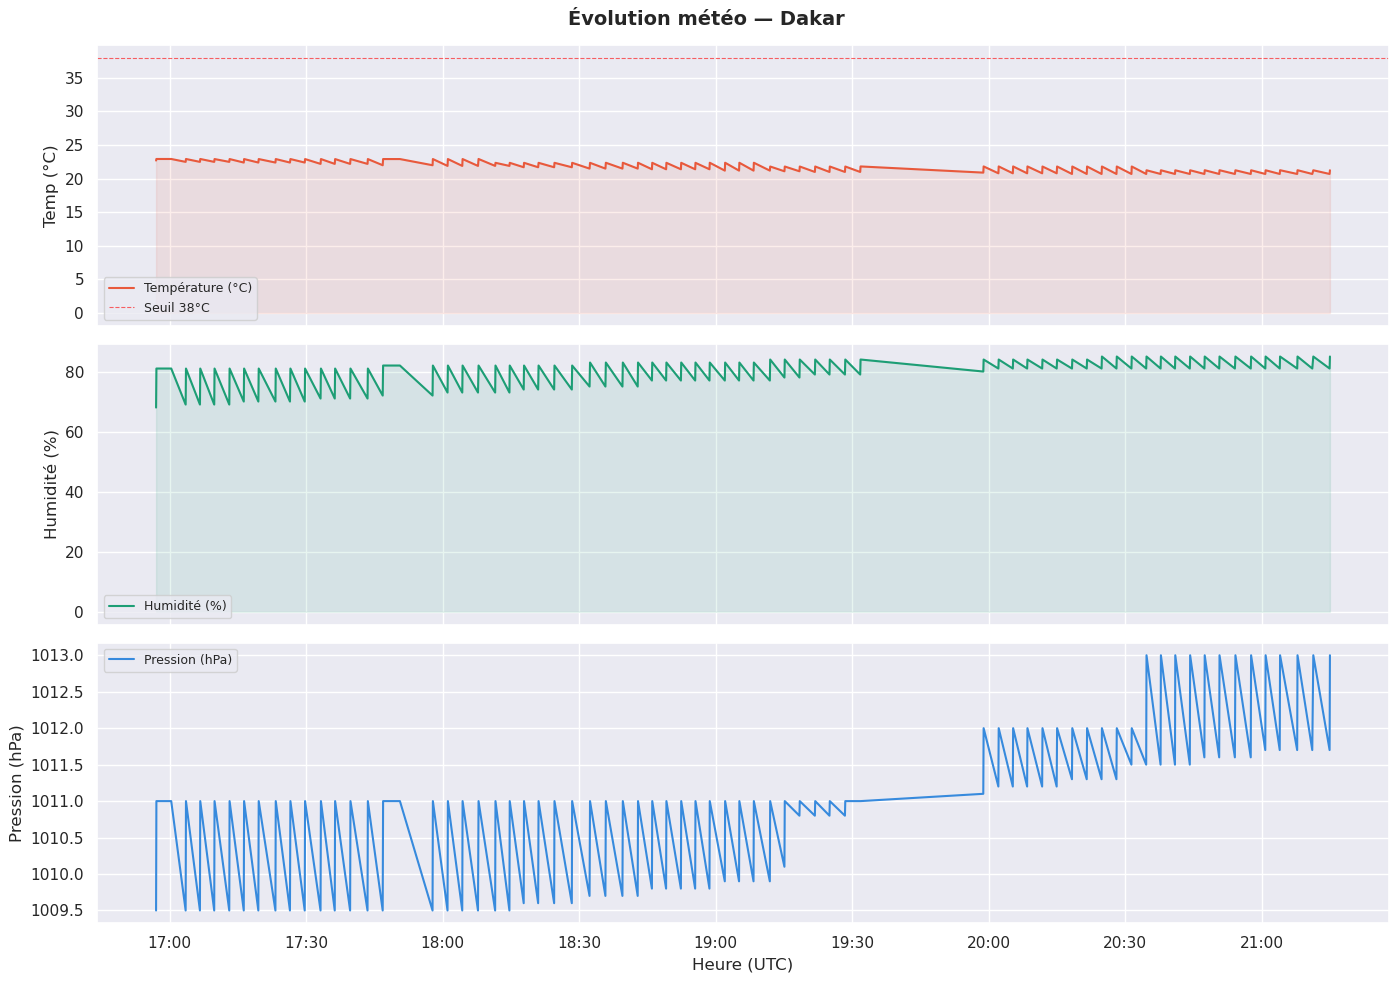

In [21]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import numpy as np

# ── PARAMÈTRES ────────────────────────────────────────────────────────────
REGION = 'Dakar'   
SEUIL  = 38
# ─────────────────────────────────────────────────────────────────────────

df = df_proc[df_proc['region'] == REGION].copy().sort_values('time')
print(f'{len(df)} points pour {REGION}')

sns.set_theme(style='darkgrid', palette='muted')
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)
fig.suptitle(f'Évolution météo — {REGION}', fontsize=14, fontweight='bold')

# Température
axes[0].plot(df['time'], df['temp'].values, color='#E8593C', linewidth=1.5, label='Température (°C)')
axes[0].axhline(SEUIL, color='red', linestyle='--', linewidth=0.8, alpha=0.6, label=f'Seuil {SEUIL}°C')
axes[0].set_ylabel('Temp (°C)')
axes[0].legend(fontsize=9)
axes[0].fill_between(df['time'].values, df['temp'].values, alpha=0.1, color='#E8593C')

# Humidité
axes[1].plot(df['time'], df['hum'].values, color='#1D9E75', linewidth=1.5, label='Humidité (%)')
axes[1].set_ylabel('Humidité (%)')
axes[1].legend(fontsize=9)
axes[1].fill_between(df['time'].values, df['hum'].values, alpha=0.1, color='#1D9E75')

# Pression
if 'pressure' in df.columns and df['pressure'].notna().any():
    axes[2].plot(df['time'], df['pressure'].values, color='#378ADD', linewidth=1.5, label='Pression (hPa)')
    axes[2].set_ylabel('Pression (hPa)')
    axes[2].legend(fontsize=9)

axes[2].xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
plt.xlabel('Heure (UTC)')
plt.tight_layout()
plt.show()

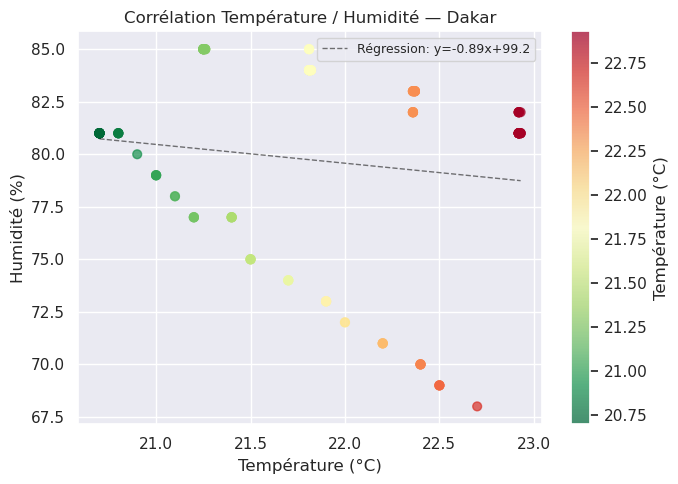

In [22]:
# Corrélation Température / Humidité
fig, ax = plt.subplots(figsize=(7, 5))
sc = ax.scatter(df['temp'].values, df['hum'].values, 
                c=df['temp'].values, cmap='RdYlGn_r', alpha=0.7, s=40)
plt.colorbar(sc, label='Température (°C)')
ax.set_xlabel('Température (°C)')
ax.set_ylabel('Humidité (%)')
ax.set_title(f'Corrélation Température / Humidité — {REGION}')

df_mask = df.dropna(subset=['temp', 'hum'])
if len(df_mask) >= 2:
    coef = np.polyfit(df_mask['temp'].values, df_mask['hum'].values, 1)
    x_line = np.linspace(df_mask['temp'].min(), df_mask['temp'].max(), 100)
    ax.plot(x_line, np.polyval(coef, x_line), 'k--', linewidth=1, alpha=0.6,
            label=f'Régression: y={coef[0]:.2f}x+{coef[1]:.1f}')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

## 4. Analyse statistique

In [23]:
from scipy import stats

df_clean = df.dropna(subset=['temp', 'hum'])
if len(df_clean) >= 2:
    r, p = stats.pearsonr(df_clean['temp'], df_clean['hum'])
    print(f'Corrélation Pearson (temp/hum) : r = {r:.4f}, p-value = {p:.4f}')
    print(f'  → {"Corrélation significative" if p < 0.05 else "Pas de corrélation significative"} (α=0.05)')
else:
    print(f'⚠️ Pas assez de données pour calculer la corrélation ({len(df_clean)} points)')


Corrélation Pearson (temp/hum) : r = -0.1417, p-value = 0.0973
  → Pas de corrélation significative (α=0.05)


## 5. Comparaison multi-régions


In [24]:
import plotly.express as px

# ── PARAMÈTRES ────────────────────────────────────────────────────────────
REGIONS_A_COMPARER = ['Dakar', 'Saint-Louis', 'Tambacounda', 'Ziguinchor']
VARIABLE_COMP      = 'temp'   # temp | hum | pressure | wind_speed
# ─────────────────────────────────────────────────────────────────────────

df_multi = df_proc[df_proc['region'].isin(REGIONS_A_COMPARER)].sort_values('time')

fig = px.line(df_multi, x='time', y=VARIABLE_COMP, color='region',
              title=f'{VARIABLE_COMP} — comparaison régions', markers=True)
fig.update_layout(template='plotly_dark', height=400)
fig.show()

## 6. Kafka en direct

In [25]:
from kafka import KafkaConsumer
import json

# ── PARAMÈTRES ────────────────────────────────────────────────────────────
N_MESSAGES = 10   # nombre de messages à lire
# ─────────────────────────────────────────────────────────────────────────

print(f'Lecture des {N_MESSAGES} derniers messages Kafka...')
consumer = KafkaConsumer(
    'senegal-meteo',
    bootstrap_servers=['kafka1:9092', 'kafka2:9093', 'kafka3:9094'],
    auto_offset_reset='latest',
    enable_auto_commit=False,
    value_deserializer=lambda b: json.loads(b.decode('utf-8')),
    consumer_timeout_ms=8000,
)

live = []
for msg in consumer:
    live.append(msg.value)
    print(f'  📨 [{msg.value.get("region","?")}] {msg.value.get("temp","?")}°C')
    if len(live) >= N_MESSAGES:
        break

consumer.close()
print(f'\n✅ {len(live)} messages reçus')
if live:
    display(pd.DataFrame(live))

Lecture des 10 derniers messages Kafka...

✅ 0 messages reçus


## 7. Export des résultats

In [15]:
# ── PARAMÈTRES ────────────────────────────────────────────────────────────
NOM_FICHIER = 'analyse_senegal.csv'   # nom du fichier CSV
# ─────────────────────────────────────────────────────────────────────────

# Export CSV local
df_proc.to_csv(NOM_FICHIER, index=False)
print(f'✅ {NOM_FICHIER} exporté localement')

# Upload vers MinIO bucket analytics
analytics_bucket = 'analytics'
if not client.bucket_exists(analytics_bucket):
    client.make_bucket(analytics_bucket)

csv_bytes = df_proc.to_csv(index=False).encode('utf-8')
client.put_object(
    analytics_bucket, f'exports/{NOM_FICHIER}',
    data=io.BytesIO(csv_bytes), length=len(csv_bytes),
    content_type='text/csv'
)
print(f'✅ Uploadé → s3://{analytics_bucket}/exports/{NOM_FICHIER}')

✅ analyse_senegal.csv exporté localement
✅ Uploadé → s3://analytics/exports/analyse_senegal.csv


## 8. Espace libre 🧪
> - Comparer deux sources (open-meteo vs openweathermap)
> - Trouver la région la plus chaude / la plus humide
> - Calculer des moyennes horaires ou journalières
> - Détecter des anomalies sur d'autres variables